In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [30]:
df = pd.read_csv("solar_system.csv")
df = df.set_index(["Attribute"])
print(df.shape) #20 rows, 11 columns
print(df.head())
print(df.tail())
print(df.index)

(20, 10)
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  
                        Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
Attribute                       

In [47]:
orbital_period = df.iloc[10].astype(float)
perihelion = df.iloc[8].astype(float)
aphelion = df.iloc[9].astype(float)
# perihelion - closest distance to sun
# aphelion - furthest distance from sun
# semimajor axis - half the distance of the longer axis of an ellipse
semi_major_axis = (perihelion + aphelion)/2
df.loc["Semi-Major Axis"] = semi_major_axis
print(df.shape) # 21 rows, 10 columns

(21, 10)


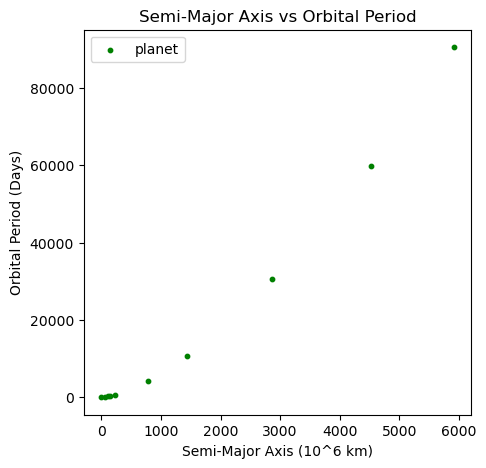

In [56]:
plt.figure(figsize=(5,5))

x = semi_major_axis
y = orbital_period

plt.scatter(x, y, c="green", s=10, label="planet")
plt.xlabel("Semi-Major Axis (10^6 km)")
plt.ylabel("Orbital Period (Days)")
plt.title("Semi-Major Axis vs Orbital Period")
plt.legend()

plt.show()

In [77]:
def keplers_third_law(a, m):
    return a * m ** 1.5

a = semi_major_axis/149.6 # converting from km to AU
T = orbital_period/365 # converting from days to years
popt, pcov = curve_fit(keplers_third_law, a, T)
m_fit = popt[0]
print(f"Fit: T = {m_fit:.2f} * a^1.5")

Fit: T = 3.17 * a^1.5


In [79]:
residuals = T - keplers_third_law(a, m_fit)
chi2 = np.sum(residuals**2)
dof = len(a) - 1
chi2_reduced = chi2 / dof
print(chi2_reduced)

252.00088736065683


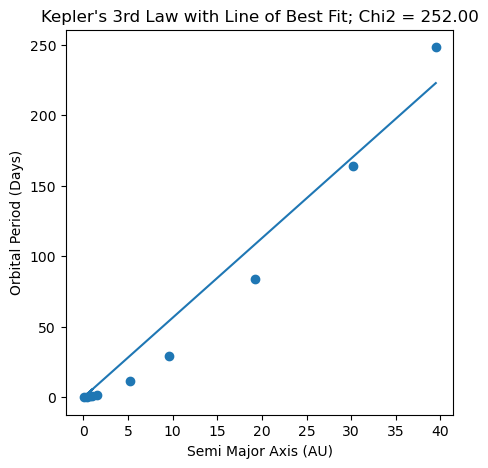

In [76]:
plt.figure(figsize=(5,5))

plt.scatter(a, T, label="Data")
plt.plot(a, keplers_third_law(a, m_fit), label="Fit")
plt.title(f"Kepler's 3rd Law with Line of Best Fit; Chi2 = {chi2_reduced:.2f}")
plt.xlabel("Semi Major Axis (AU)")
plt.ylabel("Orbital Period (Days)")

plt.show()

In [81]:
df.to_csv("kepler.csv")